In [1]:
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio as rio
from rasterio import features
from sklearn.metrics import confusion_matrix, f1_score, jaccard_score, matthews_corrcoef, cohen_kappa_score

In [2]:
#检查坐标参考系统 (CRS) 是否一致
water_gdf = gpd.read_file('water_2005.gpkg')
land_gdf  = gpd.read_file('land_2005.gpkg')
pred_src  = rio.open('../data/result/2005_pred_masked.tif')

print(water_gdf.crs)  
print(land_gdf.crs)   
print(pred_src.crs)   

EPSG:4326
EPSG:4326
EPSG:4326


In [ ]:
years = [2005, 2010, 2015, 2020]
all_data = []

for year in years:
    
    water_gdf = gpd.read_file(f'water_{year}.gpkg')
    land_gdf  = gpd.read_file(f'land_{year}.gpkg')

    water_gdf = water_gdf[~water_gdf.geometry.is_empty]
    land_gdf = land_gdf[~land_gdf.geometry.is_empty]
    
    pred_src  = rio.open(f'../data/result/{year}_pred_masked.tif')
    
    pred_array = pred_src.read(1)
    
    # 创建参考标签底图 (255为NoData)
    ref_label = np.full((pred_src.height, pred_src.width), 255, dtype='uint8')
    
    # 水体多边形 -> 赋值为 1
    shapes_water = ((geom, 1) for geom in water_gdf.geometry)
    ref_label = features.rasterize(
        shapes=shapes_water,
        out=ref_label,
        transform=pred_src.transform,
        fill=255,
        dtype='uint8'
    )
        
    # 陆地多边形 -> 赋值为 0
    shapes_land = ((geom, 0) for geom in land_gdf.geometry)
    ref_label = features.rasterize(
        shapes=shapes_land,
        out=ref_label,
        transform=pred_src.transform,
        fill=255,
        dtype='uint8'
    )
        
    # 提取有效像元 
    valid_mask = (ref_label != 255)
    
    y_true = ref_label[valid_mask]
    y_pred = pred_array[valid_mask]
    
    # 获取对应的空间位置 (行列号转化为地理坐标/经纬度)
    row_idx, col_idx = np.where(valid_mask)
    xs, ys = rio.transform.xy(pred_src.transform, row_idx, col_idx)
    
    # 将当前年份的数据追加到列表中
    year_array = np.full(y_true.shape, year, dtype=int)
    for y, x_coord, y_coord, true_val, pred_val in zip(year_array, xs, ys, y_true, y_pred):
        all_data.append([y, x_coord, y_coord, true_val, pred_val])

In [4]:
columns = ['Year', 'X', 'Y', 'True_Label', 'Pred_Label']
df_all = pd.DataFrame(all_data, columns=columns)

print(f"\n总有效样本像元数量: {len(df_all)}")
print("前5行样本:")
print(df_all.head())


总有效样本像元数量: 1636
前5行样本:
   Year          X          Y  True_Label  Pred_Label
0  2005  99.745740  37.774382           0           0
1  2005  99.746010  37.774382           0           0
2  2005  99.746279  37.774382           0           0
3  2005  99.746549  37.774382           0           0
4  2005  99.745740  37.774113           0           0


In [5]:
def print_binary_metrics(y_true, y_pred, label_names=('陆地', '水体')):
    # 计算混淆矩阵
    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    
    # 打印混淆矩阵
    cm = confusion_matrix(y_true, y_pred)
    print("混淆矩阵：")
    print(cm)
    
    # 总体精度 OA
    total = tn + fp + fn + tp
    oa = (tp + tn) / total if total > 0 else 0
    
    # Kappa 系数
    kappa = cohen_kappa_score(y_true, y_pred)
    
    # 各类别 F1
    f1_scores = f1_score(y_true, y_pred, labels=[0, 1], average=None)
    f1_0, f1_1 = f1_scores[0], f1_scores[1]
    
    # 各类别 IoU (Jaccard)
    iou_scores = jaccard_score(y_true, y_pred, labels=[0, 1], average=None)
    iou_0, iou_1 = iou_scores[0], iou_scores[1]
    
    # MCC
    mcc = matthews_corrcoef(y_true, y_pred)
    
    # 打印指标
    print(f"  Overall Accuracy (OA): {oa:.4f}")
    print(f"  Kappa 系数: {kappa:.4f}")
    print(f"  {label_names[0]} (类别0) -> F1: {f1_0:.4f}, IoU: {iou_0:.4f}")
    print(f"  {label_names[1]} (类别1) -> F1: {f1_1:.4f}, IoU: {iou_1:.4f}")
    print(f"  MCC (Matthews相关系数): {mcc:.4f}")
    
    return {
        'cm': cm,
        'oa': oa,
        'kappa': kappa,
        'f1_0': f1_0,
        'f1_1': f1_1,
        'iou_0': iou_0,
        'iou_1': iou_1,
        'mcc': mcc
    }

print_binary_metrics(df_all['True_Label'], df_all['Pred_Label'])

混淆矩阵：
[[614  27]
 [ 34 961]]
  Overall Accuracy (OA): 0.9627
  Kappa 系数: 0.9219
  陆地 (类别0) -> F1: 0.9527, IoU: 0.9096
  水体 (类别1) -> F1: 0.9692, IoU: 0.9403
  MCC (Matthews相关系数): 0.9220


{'cm': array([[614,  27],
        [ 34, 961]]),
 'oa': np.float64(0.9627139364303179),
 'kappa': np.float64(0.9219165177439698),
 'f1_0': np.float64(0.9526764934057409),
 'f1_1': np.float64(0.9692385274836107),
 'iou_0': np.float64(0.9096296296296297),
 'iou_1': np.float64(0.9403131115459883),
 'mcc': np.float64(0.92195352974022)}

C:\Users\86135\AppData\Local\Temp\ipykernel_7012\193318297.py:47: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  water_gdf.centroid.plot(ax=ax, color=water_colors[i], marker='o', markersize=18,
C:\Users\86135\AppData\Local\Temp\ipykernel_7012\193318297.py:53: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  land_gdf.centroid.plot(ax=ax, color=land_colors[i], marker='^', markersize=15,
C:\Users\86135\AppData\Local\Temp\ipykernel_7012\193318297.py:47: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  water_gdf.centroid.plot(ax=ax, color=water_colors[i], marker='o', markersize=18,


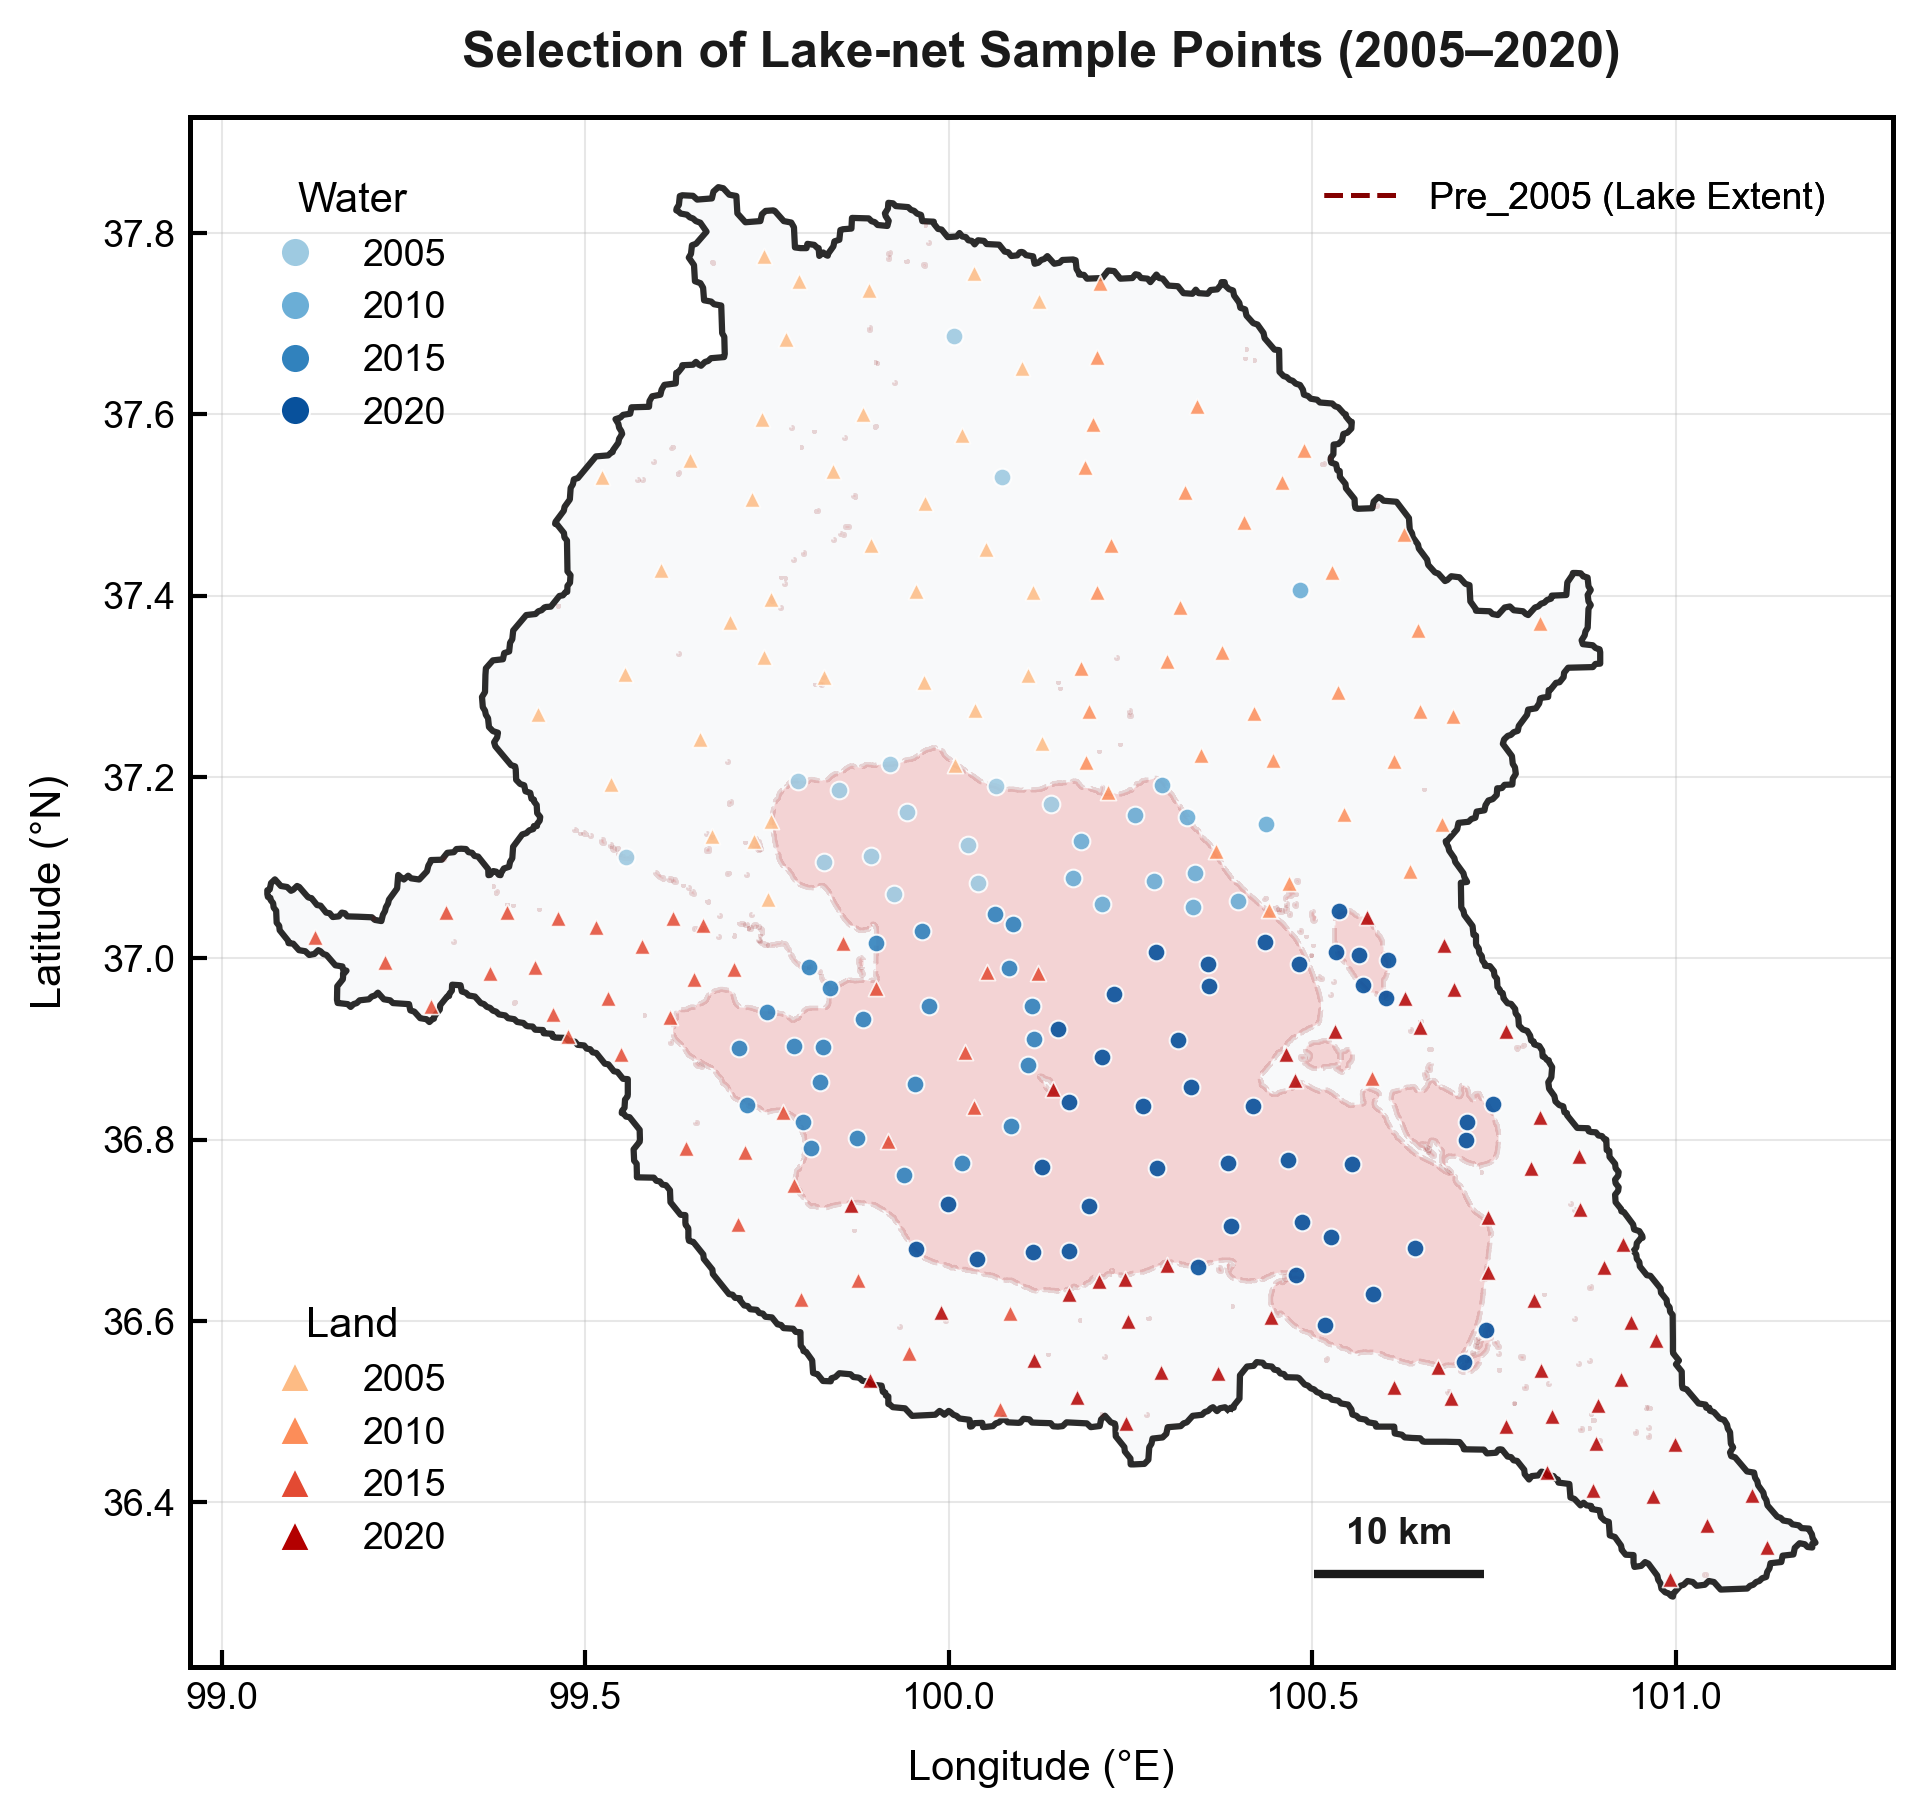

In [2]:
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.lines as mlines
import numpy as np

# 全局字体与样式设置 ( Arial, 无边框阴影, 较粗的坐标轴)
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'Helvetica', 'DejaVu Sans']
plt.rcParams['axes.linewidth'] = 1.2
plt.rcParams['mathtext.fontset'] = 'custom'

fig, ax = plt.subplots(figsize=(8, 6), dpi=300)

# 水体：从浅蓝灰到深藏青 (冷色系，干净)
water_colors = ['#9ECAE1', '#6BAED6', '#3182BD', '#08519C']
# 陆地：从香槟灰到深红棕 (暖色系，与水体形成高级对比)
land_colors  = ['#FDBB84', '#FC8D59', '#E34A33', '#B30000']
# Truth 图层：使用 NPG 风格的暗红色，降低饱和度
truth_facecolor = '#DC0000'
truth_edgecolor = '#840000'

years = [2005, 2010, 2015, 2020]

basin_gdf = gpd.read_file('qinghai_lake_basin.gpkg')
truth_gdf = gpd.read_file('2005_pred_masked.gpkg')
# --------------------------------

# 流域底图绘制 (
# 采用极浅的灰色作为底色，深灰/黑色作为边界
basin_gdf.plot(ax=ax, facecolor='#F8F9FA', edgecolor='none', zorder=1)
basin_gdf.boundary.plot(ax=ax, edgecolor='#2B2B2B', linewidth=1.5, zorder=2)

# 叠加真实数据图层 
truth_gdf = truth_gdf.to_crs(basin_gdf.crs) 
truth_gdf.plot(ax=ax, facecolor=truth_facecolor, alpha=0.15, edgecolor=truth_edgecolor,
               linewidth=1.2, linestyle='--', zorder=2.5)

# 水体和陆地质心 (精细化描边)
water_handles = []
land_handles = []

for i, year in enumerate(years):
    water_gdf = gpd.read_file(f'water_{year}.gpkg')
    land_gdf  = gpd.read_file(f'land_{year}.gpkg')

    water_gdf.centroid.plot(ax=ax, color=water_colors[i], marker='o', markersize=18,
                            alpha=0.9, edgecolor='white', linewidth=0.5, zorder=3)
    water_handles.append(mlines.Line2D([], [], color=water_colors[i], marker='o',
                                        markeredgecolor='white', markeredgewidth=0.5,
                                        linestyle='None', markersize=7, label=str(year)))
    
    land_gdf.centroid.plot(ax=ax, color=land_colors[i], marker='^', markersize=15,
                            alpha=0.85, edgecolor='white', linewidth=0.4, zorder=3)
    land_handles.append(mlines.Line2D([], [], color=land_colors[i], marker='^',
                                        markeredgecolor='white', markeredgewidth=0.5,
                                        linestyle='None', markersize=7, label=str(year)))

# 经纬网格 
if basin_gdf.crs is not None and basin_gdf.crs.is_geographic:
    ax.grid(True, linestyle='-', linewidth=0.5, alpha=0.3, color='#B0B0B0')
    ax.set_axisbelow(True)

# 标题和轴标签 
ax.set_title('Selection of Lake-net Sample Points (2005–2020)',
             fontsize=12, fontweight='bold', pad=12, color='#1A1A1A')
ax.set_xlabel('Longitude (°E)', fontsize=10, labelpad=8, fontweight='medium')
ax.set_ylabel('Latitude (°N)', fontsize=10, labelpad=8, fontweight='medium')

ax.tick_params(axis='both', which='major', labelsize=9, direction='in', length=4, width=1.0)

# 8. 图例
truth_handle = mlines.Line2D([], [], color=truth_edgecolor, linestyle='--', linewidth=1.2,
                             marker='None', label='Pre_2005 (Lake Extent)')

legend_props = {'frameon': False, 'fontsize': 9, 'title_fontsize': 10}

legend1 = ax.legend(handles=water_handles, title='Water', loc='upper left', bbox_to_anchor=(0.02, 0.98), **legend_props)
ax.add_artist(legend1)

legend2 = ax.legend(handles=land_handles, title='Land', loc='lower left', bbox_to_anchor=(0.02, 0.05), **legend_props)
ax.add_artist(legend2)

legend3 = ax.legend(handles=[truth_handle], loc='upper right', bbox_to_anchor=(0.98, 0.98), **legend_props)
ax.add_artist(legend3)

# 比例尺 
xlim = ax.get_xlim()
ylim = ax.get_ylim()
scale_length = 0.1 * (xlim[1] - xlim[0])
scale_x = xlim[0] + (xlim[1] - xlim[0]) * 0.66 
scale_y = ylim[0] + (ylim[1] - ylim[0]) * 0.06  # 稍微向上抬一点点，防止贴边

ax.plot([scale_x, scale_x + scale_length], [scale_y, scale_y],
        color='#1A1A1A', linewidth=2.0, solid_capstyle='butt')
ax.text(scale_x + scale_length/2, scale_y + (ylim[1]-ylim[0])*0.015,
        '10 km', ha='center', va='bottom', fontsize=9, fontweight='bold', color='#1A1A1A')

plt.tight_layout(pad=0.5) 
plt.show()